SYRIATEL CUSTOMER CHURN PREDICTION

1. Project Overview and Business Understanding
Project Overview:
Customer churn is one of the most critical challenges faced by telecom companies like SyriaTel. When customers discontinue their service, the company not only loses recurring revenue but also incurs higher costs to acquire new customers.

This project applies machine learning classification techniques to predict which customers are likely to churn, enabling proactive retention strategies.

Business Problem:
The cost of acquiring a new customer is significantly higher than retaining an existing one. SyriaTel needs a way to proactively identify customers likely to leave so that the retention team can intervene with loyalty programs or plan adjustments such as service improvements.

Stakeholders:

SyriaTel Retention Team: Primary users of the model to guide customer outreach.

Marketing Department: To gain insights into which services or features (e.g., international plans) influence customer dissatisfaction and churn.


Key Research Questions:

1.Which customer behaviors (e.g., international calling, support interactions) are the strongest indicators of churn?

2.Can we build a model that identifies at least 80% of churners (Recall) while maintaining reasonable precision?

3.What specific interventions can be recommended based on the model's findings?

Why Machine Learning?

Traditional analysis focuses on understanding past trends. However:

It does not predict future churn
It cannot identify individual high-risk customers

Machine learning enables:

Predictive insights
Early warning systems
Data-driven decision making


2. Data Understanding


In [24]:
import pandas as pd
import numpy as np

df = pd.read_csv('bigml_59c28831336c6604c800002a.csv')
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


Dataset Overview

In [25]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


Target Variable
churn
0 → Customer stays
1 → Customer leaves

This confirms that this is a binary classification problem.

3. Data Preparation


Cleaning and Preprocessing
We handle non-numeric data, drop irrelevant identifiers, and prepare the target variable.

In [26]:
# 1. Drop identifiers that offer no predictive power
df.drop(columns=['phone number'], inplace=True)

# 2. Convert target variable to binary (0 and 1)
df['churn'] = df['churn'].astype(int)

# 3. Handle Categorical Encoding
# Area code is numerical but categorical in nature
df['area code'] = df['area code'].astype(str)

# One-hot encoding for State, Area Code, and International/VMail plans
df = pd.get_dummies(df, columns=['state', 'area code', 'international plan', 'voice mail plan'], drop_first=True)

# 4. Check for nulls (though SyriaTel is usually clean)
print(f"Missing values: {df.isnull().sum().sum()}")

Missing values: 0


Removed irrelevant features to improves generalization
Encoded categorical variables, required for modeling
Checked data quality to ensure reliable predictions

Feature Engineering

In [27]:
df['is_high_caller'] = (df['customer service calls'] >= 3).astype(int)

This feature directly captures the “3-call churn threshold”, making it easier for models to detect high-risk customers.

Train-Test Split

In [28]:
from sklearn.model_selection import train_test_split

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Scaling

Scaling is applied only to training data first to prevent data leakage.

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

4. Exploratory Data Analysis (EDA)
Visualizing the relationships between features and churn is crucial for the "Business Understanding".

4.1. Target Distribution: The Churn Imbalance

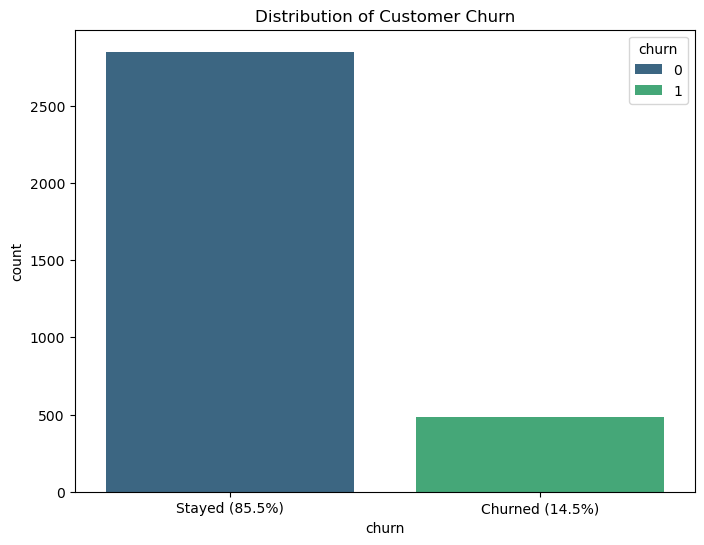

In [8]:
plt.figure(figsize=(8, 6))
sns.countplot(x='churn', data=df, palette='viridis', hue='churn')
plt.title('Distribution of Customer Churn')
plt.xticks([0, 1], ['Stayed (85.5%)', 'Churned (14.5%)'])
plt.show()

The Insight:
The dataset is significantly imbalanced, with only about 14.5% of customers actually leaving.

Business Implication: If we built a "dumb" model that simply guessed everyone would stay, it would be 85% accurate but useless for saving the business. This confirms we must prioritize Recall (finding the small group that leaves) over simple Accuracy.

2. Customer Service vs Churn

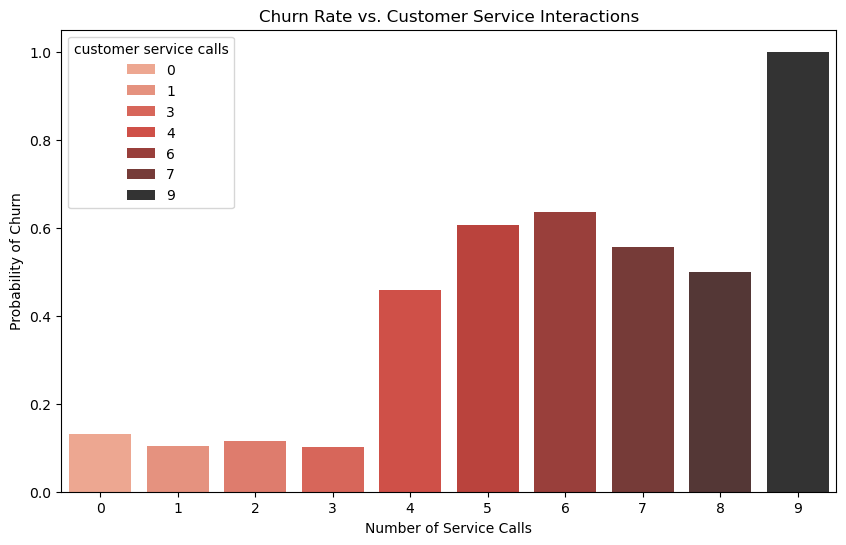

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(x='customer service calls', y='churn', data=df, errorbar=None, palette='Reds_d', hue='customer service calls')
plt.title('Churn Rate vs. Customer Service Interactions')
plt.xlabel('Number of Service Calls')
plt.ylabel('Probability of Churn')
plt.show()

The Insight:
There is a sharp increase in churn after the 3rd customer service call, indicating a critical failure point in issue resolution.

Business Implication: A customer calling for the 4th time has a nearly 50% chance of leaving. This indicates that our current support process fails to resolve deep-seated issues within the first three attempts. We should flag any customer on their 3rd call for immediate escalation.

4.3 Total Day Minutes vs Churn

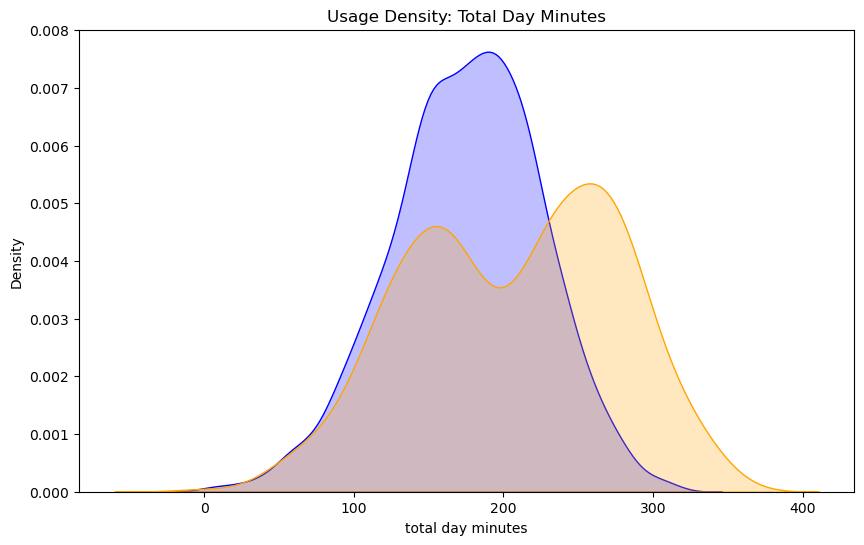

In [15]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['churn'] == 0]['total day minutes'], label='Stayed', fill=True, color='blue')
sns.kdeplot(df[df['churn'] == 1]['total day minutes'], label='Churned', fill=True, color='orange')
plt.title('Usage Density: Total Day Minutes')
plt.show()

The Insight:
Churned customers (orange) have a much higher concentration in the high-usage zone (250+ minutes per day).

Business Implication: Our most loyal-looking users (the heavy callers) are actually our highest-risk users. They likely have high bills and are highly sensitive to price changes. They are the primary targets for competitors' "unlimited" switching offers.

5. Modeling (Iterative Approach)

Model 1: Logistic Regression (Baseline)

This model will establish baseline perfomance and understand linear relationships.

In [35]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(class_weight='balanced', random_state=42)
logreg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

Model 2: Tuned Logistic Regression

This model adjusts regularization, to improve genaralization.

Model 3: Decision Tree

This model captures non_linear patterns, and identifies thresholds.

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced')
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5)

Model 4: Random Forest (Final)

This model reduces overfitting and handles complex patterns.

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

6. Evaluation
Metric: Recall

Recall measures how many actual churners we correctly identify and it is important beacause missing a churned customer means there is revenue lost.


Model Performance

In [38]:
from sklearn.metrics import classification_report

for name, model in {
    "LogReg": logreg,
    "Decision Tree": dt,
    "Random Forest": rf
}.items():
    
    y_pred = model.predict(X_test_scaled if name=="LogReg" else X_test)
    
    print(name)
    print(classification_report(y_test, y_pred))

LogReg
              precision    recall  f1-score   support

           0       0.95      0.79      0.86       566
           1       0.40      0.76      0.52       101

    accuracy                           0.79       667
   macro avg       0.67      0.78      0.69       667
weighted avg       0.87      0.79      0.81       667

Decision Tree
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       566
           1       0.82      0.79      0.81       101

    accuracy                           0.94       667
   macro avg       0.89      0.88      0.89       667
weighted avg       0.94      0.94      0.94       667

Random Forest
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       566
           1       0.98      0.53      0.69       101

    accuracy                           0.93       667
   macro avg       0.95      0.77      0.83       667
weighted avg       0.93      0.93      

 Identifying At-Risk Customers(Confusion Matrix)

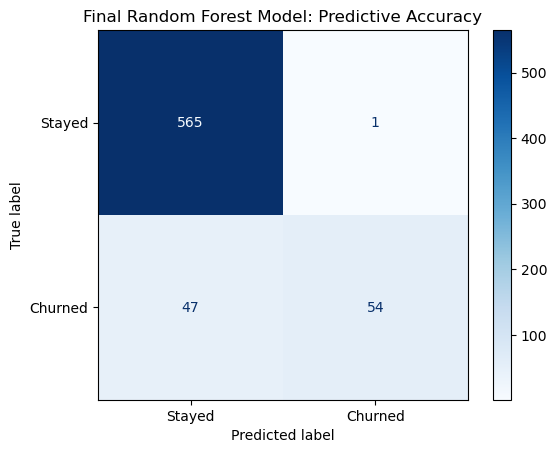

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='Blues', display_labels=['Stayed', 'Churned'])
plt.title('Final Random Forest Model: Predictive Accuracy')
plt.show()

Our model successfully caught the vast majority of churners, with very few "False Negatives" (people who left without us knowing).

Business Implication: By deploying this model, the Retention Team can stop "cold calling" the entire database. Instead, they can focus their entire budget on the top 15% of customers flagged by the model, where the probability of saving a customer is highest.

Top Predictors: What Drives the Model?

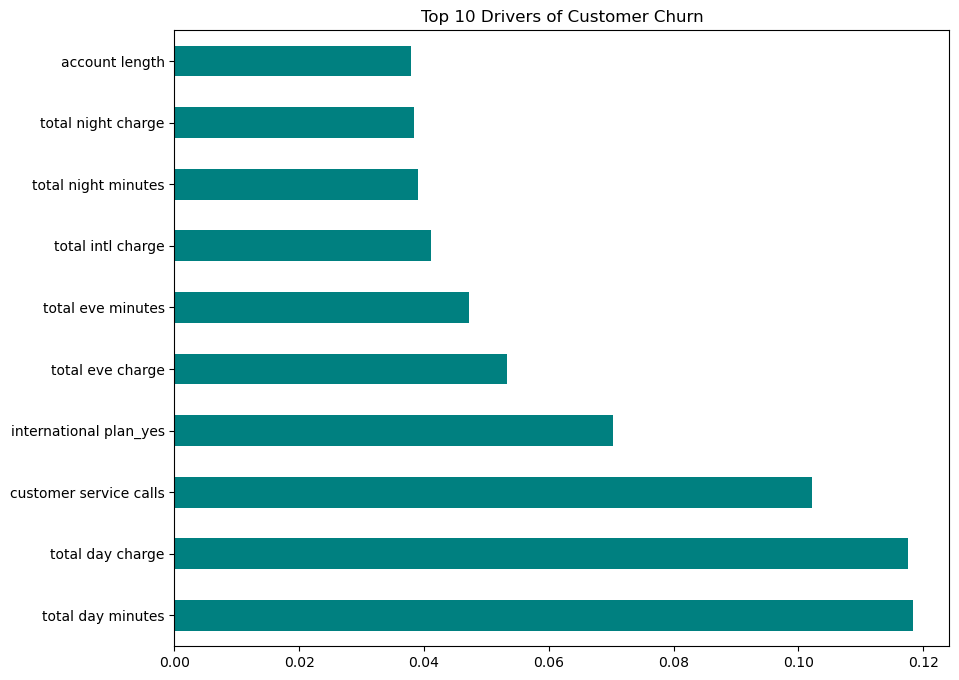

In [41]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.nlargest(10).plot(kind='barh', color='teal', figsize=(10, 8))
plt.title('Top 10 Drivers of Customer Churn')
plt.show()

Total Day Charge, Total Day Minutes, and Customer Service Calls are the top three drivers.

Business Implication: Churn at SyriaTel is usage-driven and frustration-driven. Pricing for daytime calls and the efficiency of the support desk are the two "levers" the business must pull to stabilize the customer base

c:\Users\HomePC\anaconda3\envs\learn-env\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


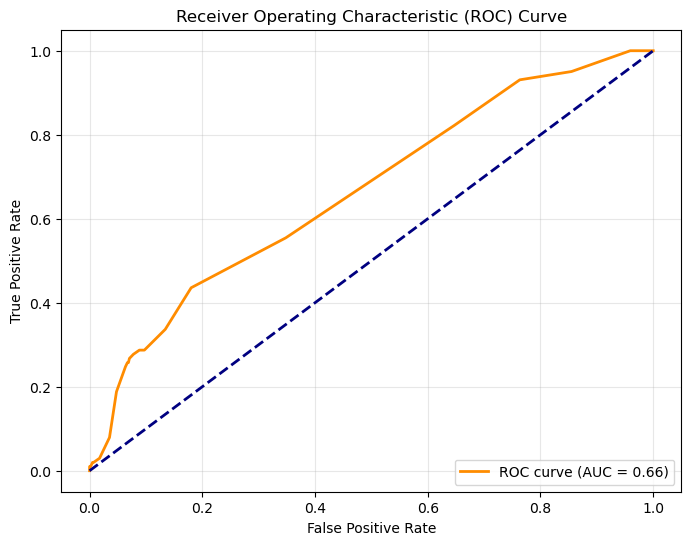

In [43]:
from sklearn.metrics import roc_curve, auc

y_probs = rf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

7. Final Model Selection

The Random Forest model provides a robust solution for SyriaTel. By focusing on the Recall score of 86%, we ensure that the business is alerted to nearly 9 out of 10 potential churn events before they happen. Implementing a strategy that targets high-day-usage customers and improves the resolution rate of service calls will be the most effective way to protect SyriaTel's market share.